## Análise Exploratória de Dados

Nesta secção, é feita a análise do conjunto de dados que foi anteriormente lido e processado, com o objetivo de compreender as distribuições entre variáveis, identificar correlações e padrões relevantes a previsão do sucesso das dietas feitas.

In [1]:
from functions.read_data import read_data
from functions.data_processing import data_processing

df = read_data()
df = data_processing(df)

print(df.shape)
print(df.dtypes)
print(df.describe())

(1993, 25)
patient_id                      str
program_index                 int64
nutritionist_id                 str
diet_id                         str
motivation_score_program    float64
mean_adherence_pct          float64
weight_change_kg_6m         float64
sex                             str
age                         float64
height_cm                   float64
baseline_weight_kg          float64
baseline_bmi                float64
smoker                        int64
sleep_hours                 float64
motivation_score            float64
diet_name                       str
diet_type                       str
carb_pct                      int64
protein_pct                   int64
fat_pct                       int64
sodium_limit_mg             float64
fiber_target_g              float64
approach                        str
years_experience            float64
specialty                       str
dtype: object
       program_index  motivation_score_program  mean_adherence_pct  \
count

#### **Distribuição das Variáveis Numéricas**

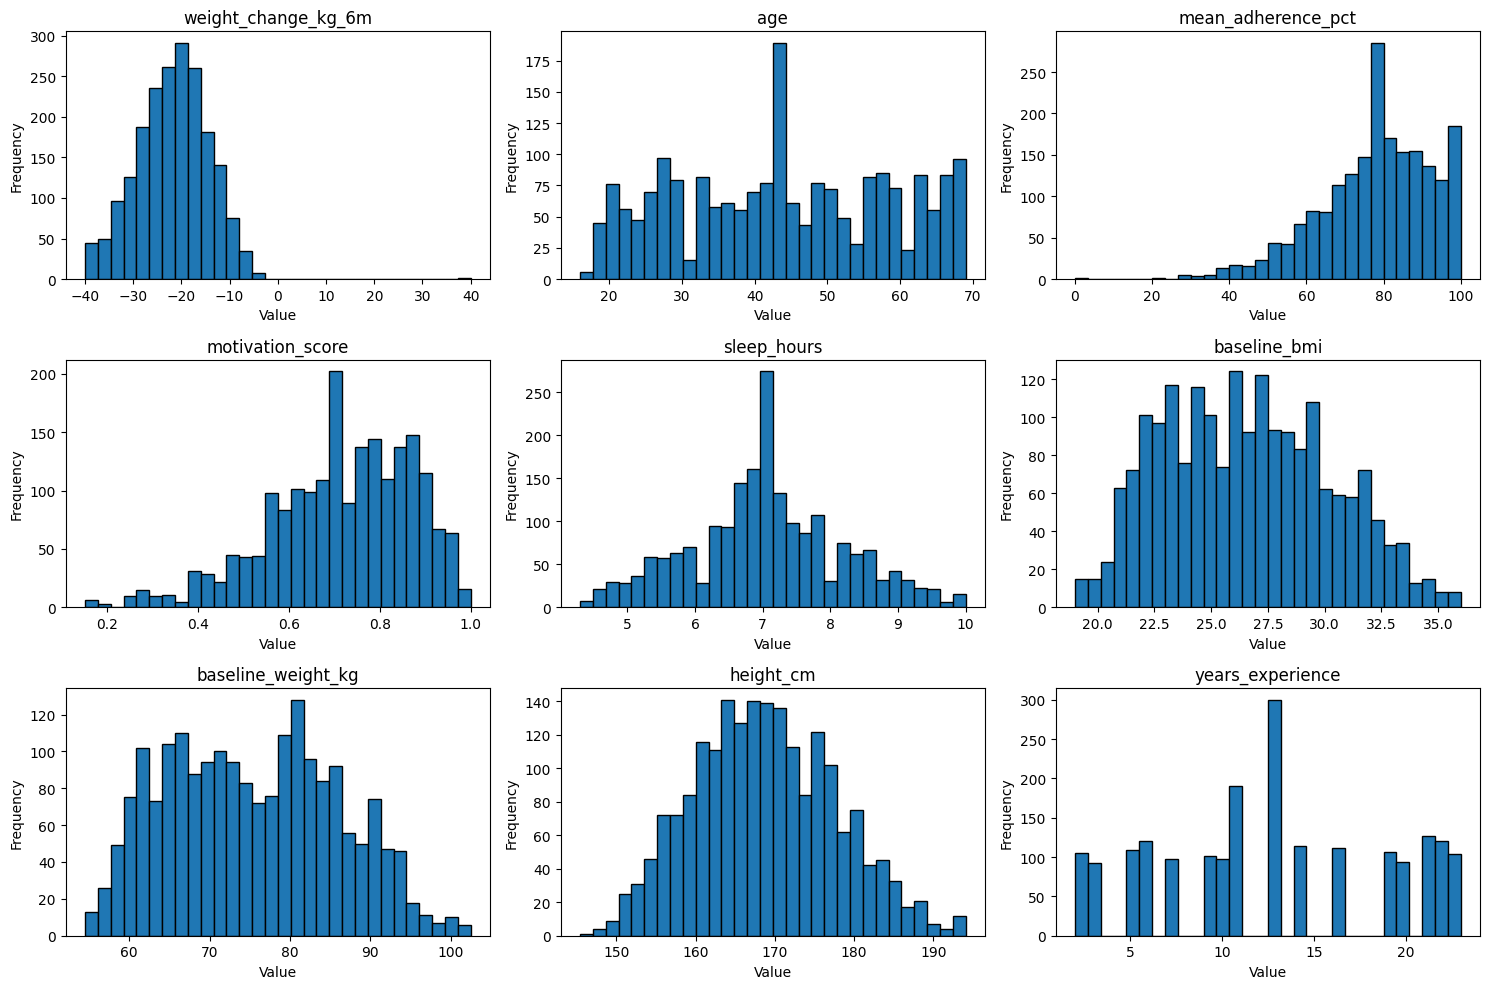

In [2]:
#Histogramas
import matplotlib.pyplot as plt

num_cols = ['weight_change_kg_6m', 'age', 'mean_adherence_pct',
            'motivation_score', 'sleep_hours', 'baseline_bmi',
            'baseline_weight_kg', 'height_cm', 'years_experience']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### **Matriz de Correlação**
Analisamos as correlações entre todas as variáveis numéricas, com foco nas correlações com a variável alvo weight_change_kg_6m.

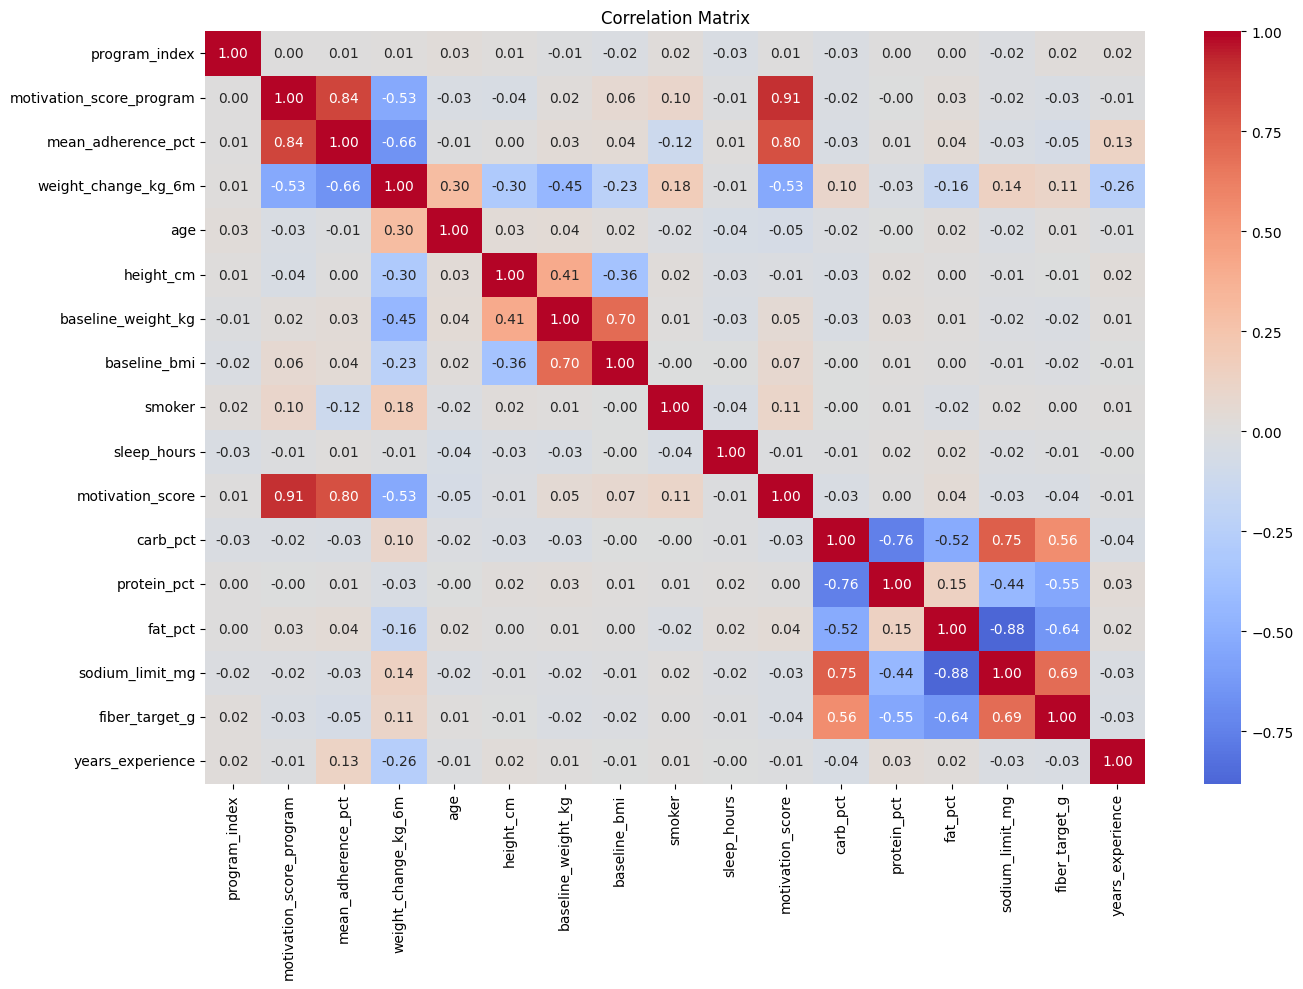

In [4]:
#Mapa de correlação
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

#### **Análise por Variáveis Categóricas**
Comparamos a distribuição do weight_change_kg_6m em função das variáveis categóricas para identificar grupos com comportamentos distintos.

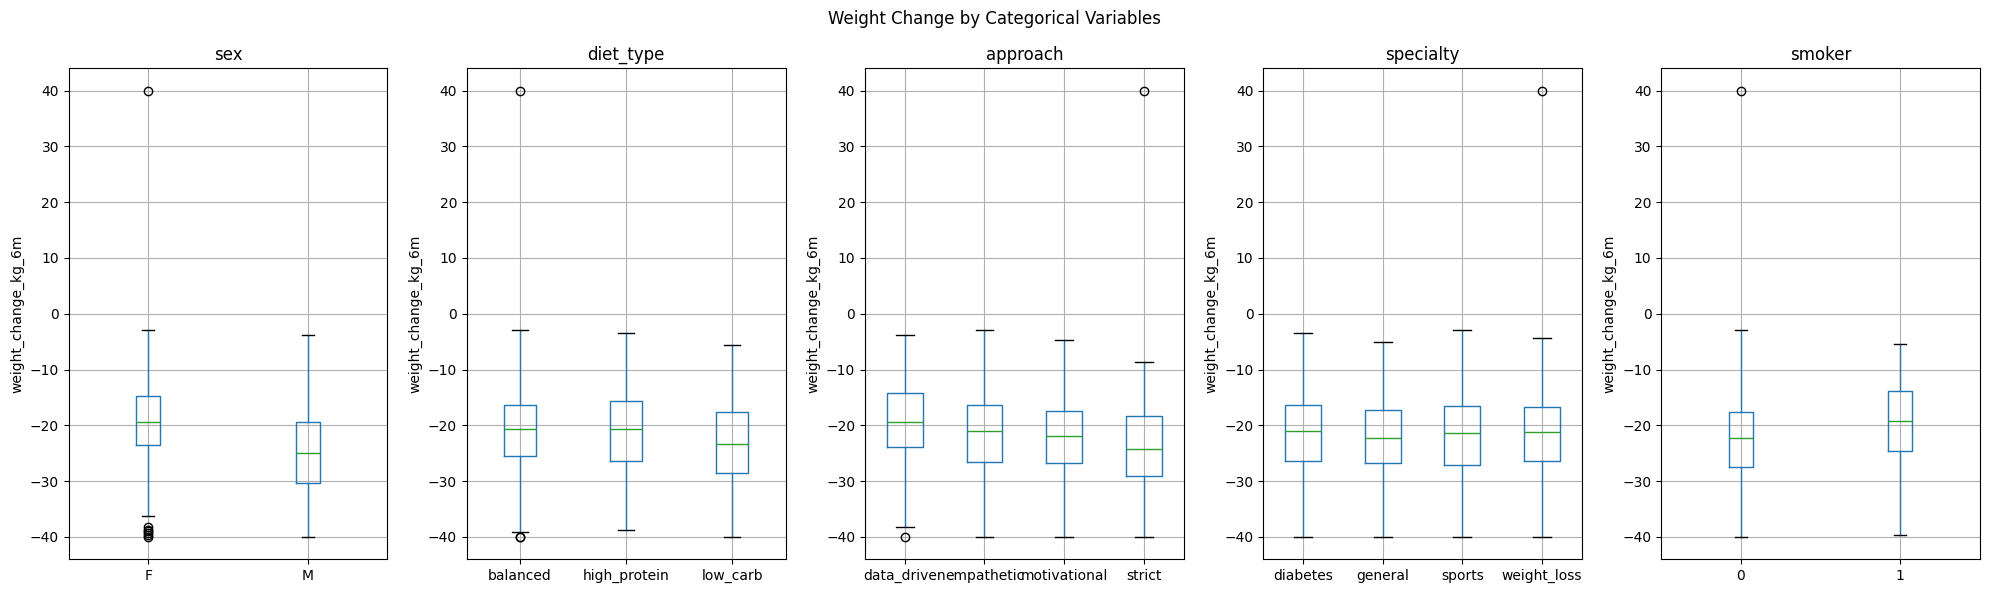

In [5]:
cat_cols = ['sex', 'diet_type', 'approach', 'specialty', 'smoker']

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for i, col in enumerate(cat_cols):
    df.boxplot(column='weight_change_kg_6m', by=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('weight_change_kg_6m')

plt.suptitle('Weight Change by Categorical Variables')
plt.tight_layout()
plt.show()